In [18]:
import os
import json

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    'font.serif': ['Computer Modern'],
})

import re

def tex_safe(text):
    # This keeps your source 'text' original, but returns a 
    # version LaTeX won't choke on.
    return text.replace("%", r"\%")#.replace("_", r"\_")

# Ensure the ARM64 path is active in the environment
tex_bin = os.path.expanduser("~/texlive/bin/aarch64-linux")
if tex_bin not in os.environ["PATH"]:
    os.environ["PATH"] = f"{tex_bin}:{os.environ['PATH']}"

# Use the absolute path to run tlmgr
!tlmgr install fontext
!tlmgr install cm-super type1cm dvipng
!tlmgr install amsmath amsfonts symbol listings xcolor
!{tex_bin}/tlmgr install underscore geometry graphics
!{tex_bin}/texhash

tlmgr: package repository https://mirror.init7.net/ctan/systems/texlive/tlnet (verified)
tlmgr install: package fontext not present in repository.
tlmgr: action install returned an error; continuing.
tlmgr: An error has occurred. See above messages. Exiting.
tlmgr: package repository https://mirror.init7.net/ctan/systems/texlive/tlnet (verified)
tlmgr install: package already present: cm-super
tlmgr install: package already present: dvipng
tlmgr install: package already present: type1cm
tlmgr: package repository https://mirror.init7.net/ctan/systems/texlive/tlnet (verified)
tlmgr install: package already present: amsfonts
tlmgr install: package already present: amsmath
tlmgr install: package already present: listings
tlmgr install: package already present: symbol
tlmgr install: package already present: xcolor
tlmgr: package repository https://mirror.init7.net/ctan/systems/texlive/tlnet (verified)
tlmgr install: package already present: geometry
tlmgr install: package already present: g

In [19]:
RAW_RUN_CSVS = [
# f"{os.getcwd()}/artifacts_saved/combined_wandb_data_20251120-210658.csv",
# f"{os.getcwd()}/artifacts_saved/combined_wandb_data_20251121-085035.csv",
f"{os.getcwd()}/artifacts_saved/combined_wandb_data_20251122-170707.csv",
f"{os.getcwd()}/artifacts_saved/combined_wandb_data_20251122-193525.csv",
]

FIGURES_OUT_DIR = f"{os.getcwd()}/auto_figures"

In [20]:
def load_and_combine_csvs(csv_paths):
    df_list = [pd.read_csv(csv_path) for csv_path in csv_paths]
    combined_df = pd.concat(df_list, ignore_index=True)
    return combined_df

def fix_cols(df):

    # add Text for each of those
    gen_table_columns = ["Prompt", "GT Compl", "AR Teach Gen", "AR Stud Gen", "SS Stud Gen"]
    for c in gen_table_columns:
        new_col = f"{c} Text"
        if c in df.columns:
            df.rename(columns={c: new_col}, inplace=True)
    loss_columns = ["GT_Compl", "AR_Teach_Gen", "AR_Stud_Gen", "SS_Stud_Gen"]
    loss_columns += [f"{c}_kx0" for c in loss_columns]
    loss_columns += [f"{c}_kx1" for c in loss_columns]
    loss_columns += [f"{c}_kx2" for c in loss_columns]
    for col in df.columns:
        if any(col == lc for lc in loss_columns):
            new_col = col + " Loss"
            df.rename(columns={col: new_col}, inplace=True)

    return df 

In [21]:
raw_df = load_and_combine_csvs(RAW_RUN_CSVS)
raw_df = fix_cols(raw_df)
print(f"Combined dataframe shape: {raw_df.shape}")
print(f"Column names and types:\n{raw_df.dtypes}")
raw_df

Combined dataframe shape: (5984, 354)
Column names and types:
run_id                                       object
step                                          int64
sub_table_index                               int64
Prompt Text                                  object
GT Compl Text                                object
                                             ...   
model_config.shared_attention_norm             bool
model_config.sliding_window_indices         float64
model_config.attention_scores_scalar        float64
model_config.final_logit_softcapping        float64
model_config.attention_logit_softcapping    float64
Length: 354, dtype: object


,run_id,step,sub_table_index,Prompt Text,GT Compl Text,AR Teach Gen Text,AR Stud Gen Text,SS Stud Gen Text,run_name,artifact_timestamp,...,model_config.post_attention_norm,model_config.rope_condense_ratio,model_config.sliding_window_size,model_config.rope_local_base_freq,model_config.moe_intermediate_size,model_config.shared_attention_norm,model_config.sliding_window_indices,model_config.attention_scores_scalar,model_config.final_logit_softcapping,model_config.attention_logit_softcapping
0,0quahq5c,47000,0,The philosophy of progressive education flows ...,an advice to prospective mentors:\n,a passage:\nThe child is,a passage:\nThe first thing,<ss0> advice wisdom<ss1>: “<ss2>The child,debug_bda_largeN_k2_ss_L3-8B_FinewebEdu_toks22...,2025-11-21T03:04:11Z,...,False,1,NaN,NaN,NaN,False,NaN,NaN,NaN,NaN
1,0quahq5c,47000,1,Can you think of creating a shape that would g...,"\nTo see the reflection,","\nNo, you will not","\nNo, you will not","<ss0>\nNo<ss1>, you<ss2> will not",debug_bda_largeN_k2_ss_L3-8B_FinewebEdu_toks22...,2025-11-21T03:04:11Z,...,False,1,NaN,NaN,NaN,False,NaN,NaN,NaN,NaN
2,0quahq5c,47000,2,Williams graduated from the local State Normal...,a partner of Ferdinand Lee Barnett,the only black lawyer in the,the only black lawyer in the,<ss0> the city<ss1>’s only<ss2> black lawyer,debug_bda_largeN_k2_ss_L3-8B_FinewebEdu_toks22...,2025-11-21T03:04:11Z,...,False,1,NaN,NaN,NaN,False,NaN,NaN,NaN,NaN
3,0quahq5c,47000,3,physical environment fosters optimal growth a...,"safe, clean, attractive,","safe, clean, and well","safe, clean, and well",<ss0> designed to<ss1> provide the<ss2> childr...,debug_bda_largeN_k2_ss_L3-8B_FinewebEdu_toks22...,2025-11-21T03:04:11Z,...,False,1,NaN,NaN,NaN,False,NaN,NaN,NaN,NaN
4,0quahq5c,47000,4,control 4.9 ± 1.1 and 13.2 ± 1.1 hours.\nFoll...,"3%, 95% CI","1%, 95% CI","1%, 95% CI","<ss0>1%,<ss1> 95<ss2>% CI",debug_bda_largeN_k2_ss_L3-8B_FinewebEdu_toks22...,2025-11-21T03:04:11Z,...,False,1,NaN,NaN,NaN,False,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5979,dkb2k1p3,165500,27,15) suggested that the objective neural event...,"philosophers have called free will """,neuroscientists have been reluctant,researchers have argued that the feeling,<ss0> of have argued<ss1> that the feeling,debug_bda_largeN_k3_ss_L3-8B_FinewebEdu_toks22...,2025-11-23T03:06:12Z,...,False,1,NaN,NaN,NaN,False,NaN,NaN,NaN,NaN
5980,dkb2k1p3,165500,28,", regular aerobic exercise not only has benefi...",Chronic Pain Subjects. Curr,Chronic Pain Populations. J,Clinical Populations. J Strength,<ss0> Clinicalased.<ss1> J Med.,debug_bda_largeN_k3_ss_L3-8B_FinewebEdu_toks22...,2025-11-23T03:06:12Z,...,False,1,NaN,NaN,NaN,False,NaN,NaN,NaN,NaN
5981,dkb2k1p3,165500,29,1981-1982. These study groups have made many ...,primary force behind code reform.,major factor in the reduction of,major factor in the reduction of,<ss0> major factor in<ss1> the reduction of,debug_bda_largeN_k3_ss_L3-8B_FinewebEdu_toks22...,2025-11-23T03:06:12Z,...,False,1,NaN,NaN,NaN,False,NaN,NaN,NaN,NaN
5982,dkb2k1p3,165500,30,spacecraft with no way of going to space. The...,"a freak ""static firing""",a test firing. The explosion,a static fire test. The,<ss0> a static test<ss1> fire. Atlas,debug_bda_largeN_k3_ss_L3-8B_FinewebEdu_toks22...,2025-11-23T03:06:12Z,...,False,1,NaN,NaN,NaN,False,NaN,NaN,NaN,NaN


Fig name: corr_SS_Stud_Gen_top1_confs_vs_SS_Stud_Gen_Loss_largeN_k3_ss_steps_117000-165500.png
Saved figure to: /capstor/scratch/cscs/jkirchen/singleshot-root/singleshot/auto_figures/corr_SS_Stud_Gen_top1_confs_vs_SS_Stud_Gen_Loss_largeN_k3_ss_steps_117000-165500.png


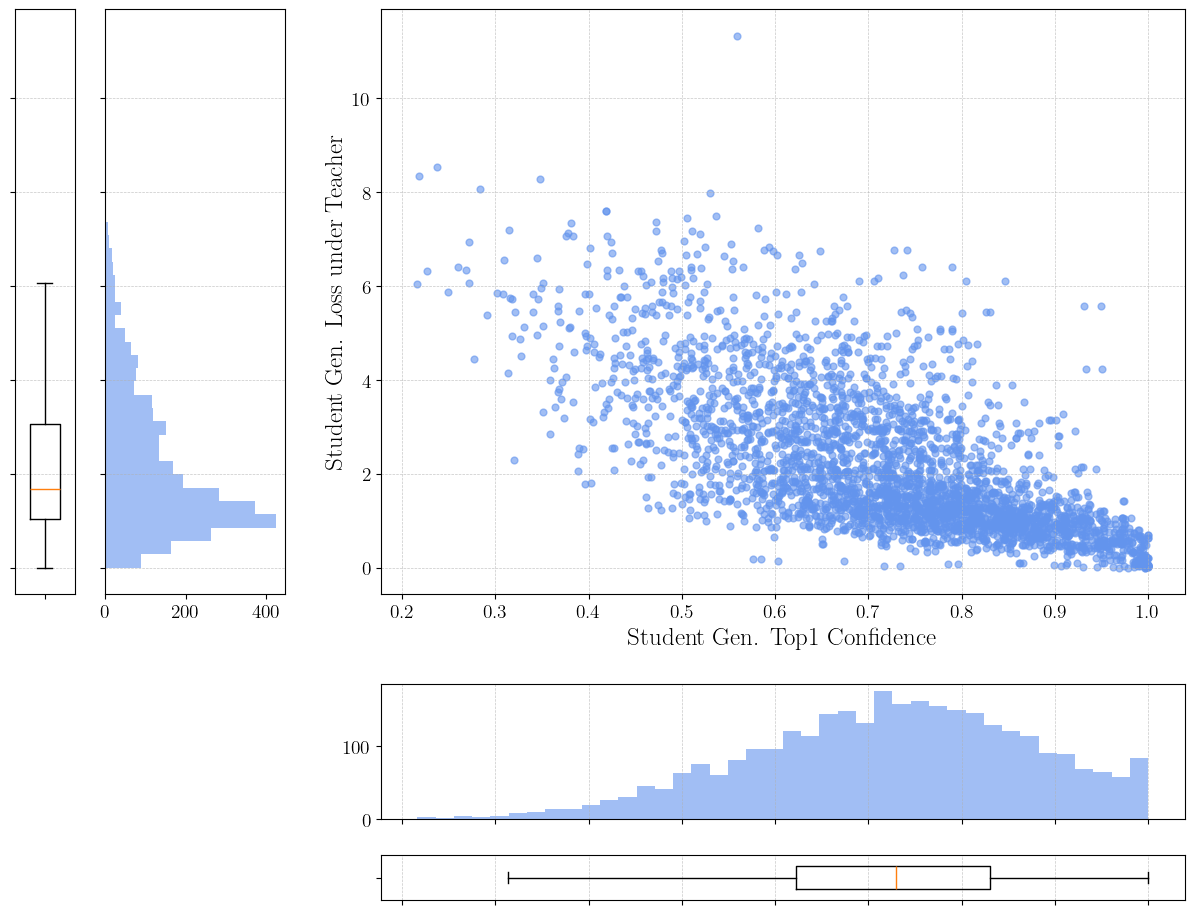

In [27]:
SAVE_FIGS = True
# SAVE_FIGS = False


# make text and line size larger
# print(plt.rcParams.keys())
fig_size = (10,7)
marker_size = 24
plt.rcParams.update({
    "font.size": 16,
    "axes.titlesize": 18,
    "axes.labelsize": 18,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14,
    "legend.markerscale": 1.2,
    "lines.linewidth": 2.0
})



# filter the df based on whatever

# keystr = 'largeN_k2_ss'
keystr = 'largeN_k3_ss'
filtered_df = raw_df[raw_df['run_name'].str.contains(keystr)]

# cuttoff for all steps
step_min = filtered_df['step'].min()
step_max = filtered_df['step'].max()
# # cuttoff for earliest 33% of steps
# step_min = filtered_df['step'].min()
# step_max = filtered_df['step'].quantile(0.33)
# # cuttoff for middle 33% of steps
# step_min = filtered_df['step'].quantile(0.33)
# step_max = filtered_df['step'].quantile(0.66)
# cuttoff for latest 33% of steps
# step_min = filtered_df['step'].quantile(0.66)
# step_max = filtered_df['step'].max()

filtered_df = filtered_df[(filtered_df['step'] >= step_min) & (filtered_df['step'] <= step_max)]

# filtered_df

y_axis_limits = None
# y_axis_limits = (-1, 14)
# y_axis_limits = (0, 1)

reverse_x_axis = False
# reverse_x_axis = True

log_y = False
# log_y = True

log_x = False
# log_x = True

log_scale_y = False
# log_scale_y = True

log_scale_x = False
# log_scale_x = True

# Is the necessary corr there to suspect that low conf causes bad SS loss?
cols = ["SS_Stud_Gen/top1_confs", "SS_Stud_Gen Loss"]
# cols = ["SS_Stud_Gen_kx0/top1_confs", "SS_Stud_Gen_kx0 Loss"]
# cols = ["SS_Stud_Gen_kx1/top1_confs", "SS_Stud_Gen_kx1 Loss"]
# cols = ["SS_Stud_Gen_kx2/top1_confs", "SS_Stud_Gen_kx2 Loss"]

# Do indiv rollout attempts affect the other ones in the sequence?
# cols = ["SS_Stud_Gen_kx0 Loss", "SS_Stud_Gen Loss"]
# cols = ["SS_Stud_Gen_kx1 Loss", "SS_Stud_Gen Loss"]
# cols = ["SS_Stud_Gen_kx2 Loss", "SS_Stud_Gen Loss"]
# cols = ["SS_Stud_Gen_kx0 Loss", "SS_Stud_Gen_kx1 Loss"]
# cols = ["SS_Stud_Gen_kx0 Loss", "SS_Stud_Gen_kx2 Loss"]
# cols = ["SS_Stud_Gen_kx1 Loss", "SS_Stud_Gen_kx2 Loss"]

# Can some of the SS loss variation be explained by AR or GT variation?
# cols = ["AR_Stud_Gen Loss", "SS_Stud_Gen Loss"]
# cols = ["AR_Teach_Gen Loss", "SS_Stud_Gen Loss"]
# cols = ["GT_Compl Loss", "SS_Stud_Gen Loss"]

# Sub relation, can the SS conf variation be explained by AR or GT variation?
# cols = ["SS_Stud_Gen Loss", "SS_Stud_Gen/top1_confs"]
# cols = ["AR_Stud_Gen Loss", "SS_Stud_Gen/top1_confs"]
# cols = ["AR_Teach_Gen Loss", "SS_Stud_Gen/top1_confs"]
# cols = ["GT_Compl Loss", "SS_Stud_Gen/top1_confs"]

# some other misc plots
# cols = ["SS_Stud_Gen/ents", "SS_Stud_Gen Loss"]
# cols = ["SS_Stud_Gen/repetition_1", "SS_Stud_Gen Loss"]
# cols = ["SS_Stud_Gen_kx0/repetition_1", "SS_Stud_Gen_kx0 Loss"]
# cols = ["SS_Stud_Gen_kx1/repetition_1", "SS_Stud_Gen_kx1 Loss"]
# cols = ["SS_Stud_Gen_kx0/repetition_1", "SS_Stud_Gen_kx1/repetition_1"]
# cols = ["AR_Stud_Gen/repetition_1", "AR_Stud_Gen Loss"]


COL_NAME_MAP = {
    "SS_Stud_Gen/top1_confs": "Student Gen. Top1 Confidence",
    "SS_Stud_Gen Loss": "Student Gen. Loss under Teacher",
}


def make_fig_filename(cols, keystr, step_min, step_max, log_x, log_y, reverse_x_axis):
    logx_str = "_logx" if log_x else ""
    logy_str = "_logy" if log_y else ""
    logx_scale_str = "_logscalex" if log_scale_x else ""
    logy_scale_str = "_logscaley" if log_scale_y else ""
    revx_str = "_revx" if reverse_x_axis else ""
    filename = f"corr_{cols[0].replace('/', '_')}_vs_{cols[1].replace('/', '_')}_{keystr}_steps_{int(step_min)}-{int(step_max)}{logx_str}{logy_str}{logx_scale_str}{logy_scale_str}{revx_str}.png".replace(' ', '_')
    return filename


plt.figure(figsize=(fig_size[0]+2, fig_size[1]+2))

if all(c in filtered_df.columns for c in cols):
    plot_df = filtered_df[cols].dropna()
    if not plot_df.empty:
        
        if log_x:
            plot_df[cols[0]] = np.log(plot_df[cols[0]])
        if log_y:
            plot_df[cols[1]] = np.log(plot_df[cols[1]])

        r = plot_df.corr().iloc[0, 1]
        m, b = np.polyfit(plot_df[cols[0]], plot_df[cols[1]], 1)
        x = np.linspace(plot_df[cols[0]].min(), plot_df[cols[0]].max(), 100)

        # Parameters
        hist_height = 0.15
        gap = 0.1
        bottom_margin = 0.05  # fixed bottom margin

        # Current main axis position
        # pos = ax_main.get_position()
        
        # Determine the initial position of the main plot, giving space for 
        # the bottom and left side histograms.

        # Initial plot boundaries (normalized figure coordinates 0 to 1)
        left_margin = 0.05
        right_margin = 0.05
        top_margin = 0.05
        
        # Calculate space needed for histograms and gaps
        hist_height_norm = 0.15
        hist_width_norm = 0.15
        x_gap_norm = 0.1
        y_gap_norm = 0.08
        
        x_hist_pos = left_margin
        y_hist_pos = top_margin
        
        # Main plot position
        # It needs space from the bottom for the x-histogram
        bottom = bottom_margin + hist_height_norm + x_gap_norm 
        # It needs space from the left for the y-histogram
        left = left_margin + hist_width_norm + y_gap_norm
        # Main plot right (standard margin from 1.0)
        right = 1.0 - right_margin
        # Main plot top (standard margin from 1.0)
        top = 1.0 - top_margin
        
        # Define main axes position
        main_ax_pos = [left, bottom, right - left, top - bottom]
        
        # Create the main axes
        fig = plt.gcf()
        ax_main = fig.add_axes(main_ax_pos)
        
        # Plot data on main axis
        ax_main.scatter(plot_df[cols[0]], plot_df[cols[1]], s=marker_size, alpha=0.6, c="#6394ED")
        # ax_main.plot(x, m * x + b, color="red")

        col0_name = COL_NAME_MAP.get(cols[0], cols[0])
        col1_name = COL_NAME_MAP.get(cols[1], cols[1])
        
        if y_axis_limits is not None:
            ax_main.set_ylim(y_axis_limits)

        if log_x:
            # ax_main.set_xlabel(f"log({cols[0]})")
            ax_main.set_xlabel(f"log({col0_name})")
        else:
            # ax_main.set_xlabel(cols[0])
            ax_main.set_xlabel(col0_name)
        if log_y:
            # ax_main.set_ylabel(f"log({cols[1]})")
            ax_main.set_ylabel(f"log({col1_name})")
        else:
            # ax_main.set_ylabel(cols[1])
            ax_main.set_ylabel(col1_name)
        if reverse_x_axis:
            ax_main.invert_xaxis()

        if log_scale_x:
            ax_main.set_xscale("log")
        if log_scale_y:
            ax_main.set_yscale("log")

        linfit_yexpor = "log(y)" if log_y else "y"
        linfit_xexpr = "log(x)" if log_x else "x"
        linfit_expr = f"{linfit_yexpor}$\\propto${m:.3f}{linfit_xexpr}"
        # ax_main.set_title(f"{cols[0]} vs. {cols[1]}\n{keystr} from steps=({int(step_min)},{int(step_max)})\nn={len(plot_df)}, {linfit_expr}, R={r:.3f}, $R^2$={r**2:.3f}")
        # ax_main.set_title(f"{col0_name} vs. {col1_name}\nn={len(plot_df)}, {linfit_expr}, R={r:.3f}, $R^2$={r**2:.3f}")
        # ax_main.set_title(f"{col0_name} vs. {col1_name}")

        # turn on grid
        ax_main.grid(True, which="both", linestyle="--", linewidth=0.5, alpha=0.7)
        
        # Get the final position of the main axis for alignment
        pos_main = ax_main.get_position()
        
        # Add X-axis histogram, aligned below
        ax_hist_x = fig.add_axes([pos_main.x0, bottom_margin, pos_main.width, hist_height_norm], sharex=ax_main)
        ax_hist_x.hist(plot_df[cols[0]], bins=40, color="#6394ED", alpha=0.6)
        ax_hist_x.tick_params(axis="x", labelbottom=False) # remove x-ticks/labels to avoid overlap with main plot x-axis label
        ax_hist_x.set_ylabel("") # remove y-label
        ax_hist_x.tick_params(axis="y")

        # also make a box plot on top of the x-histogram but align it with the x ticks already present
        ax_box_x = fig.add_axes([pos_main.x0, bottom_margin - 0.6*hist_height_norm, pos_main.width, 0.05], sharex=ax_main)
        ax_box_x.boxplot(plot_df[cols[0]], vert=False, widths=0.5, showfliers=False)
        ax_box_x.tick_params(axis="x", labelbottom=False) # remove x-ticks/labels
        ax_box_x.set_yticklabels([]) # remove y-tick labels
        ax_box_x.set_ylabel("") # remove y-label

        # turn on grid only in the axis that have ticks
        ax_hist_x.grid(True, which="both", axis="x", linestyle="--", linewidth=0.5, alpha=0.7)
        ax_box_x.grid(True, which="both", axis="x", linestyle="--", linewidth=0.5, alpha=0.7)
        
        # Add Y-axis histogram, aligned to the LEFT of the main plot
        # Position is left_margin, then width is hist_width_norm, then gap is y_gap_norm, then main plot starts.
        ax_hist_y = fig.add_axes([left_margin, pos_main.y0, hist_width_norm, pos_main.height], sharey=ax_main)
        ax_hist_y.hist(plot_df[cols[1]], bins=40, orientation='horizontal', color="#6394ED", alpha=0.6)
        ax_hist_y.tick_params(axis="y", labelleft=False) # keep y-ticks/labels on the left-side histogram
        ax_hist_y.set_xlabel("") # remove x-label
        ax_hist_y.tick_params(axis="x")

        # also make a box plot on the side of the y-histogram but align it with the y ticks already present
        ax_box_y = fig.add_axes([left_margin - 0.5*hist_width_norm, pos_main.y0, 0.05, pos_main.height], sharey=ax_main)
        ax_box_y.boxplot(plot_df[cols[1]], vert=True, widths=0.5, showfliers=False)
        ax_box_y.tick_params(axis="y", labelleft=False) # remove y-ticks/labels
        ax_box_y.set_xticklabels([]) # remove x-tick labels
        ax_box_y.set_xlabel("") # remove x-label

        # turn on grid only in the axis that have ticks
        ax_hist_y.grid(True, which="both", axis="y", linestyle="--", linewidth=0.5, alpha=0.7)
        ax_box_y.grid(True, which="both", axis="y", linestyle="--", linewidth=0.5, alpha=0.7)

        # # finally, add a legend in bottom left corner of free space with
        # legend_str = f"n={len(plot_df)}\n{linfit_expr}\nR={r:.3f}\n$R^2$={r**2:.3f}"
        # ax_hist_x.text(-0.23, 0.52, legend_str, transform=ax_hist_x.transAxes,
        #                 horizontalalignment='center', verticalalignment='center', fontsize=18,
        #                 bbox=dict(facecolor='white', alpha=0.8, edgecolor='black', boxstyle='round,pad=0.3'))



        # save figure
        fig_filename = make_fig_filename(cols, keystr, step_min, step_max, log_x, log_y, reverse_x_axis)
        print(f"Fig name: {fig_filename}")
        if SAVE_FIGS:
            if not os.path.exists(FIGURES_OUT_DIR):
                os.makedirs(FIGURES_OUT_DIR)
            fig_path = os.path.join(FIGURES_OUT_DIR, fig_filename)
            plt.savefig(fig_path, bbox_inches='tight')
            print(f"Saved figure to: {fig_path}")
        
        plt.show()
    else:
        print("No data after dropping NA.")
else:
    missing = [c for c in cols if c not in filtered_df.columns]
    print(f"Missing columns: {missing}")

No data after dropping NA for columns: ['SS_Stud_Gen_kx2/top1_confs', 'SS_Stud_Gen_kx2 Loss']
Fig name: corr_multiple_plots_largeN_k3_ss_steps_117000-165500.png


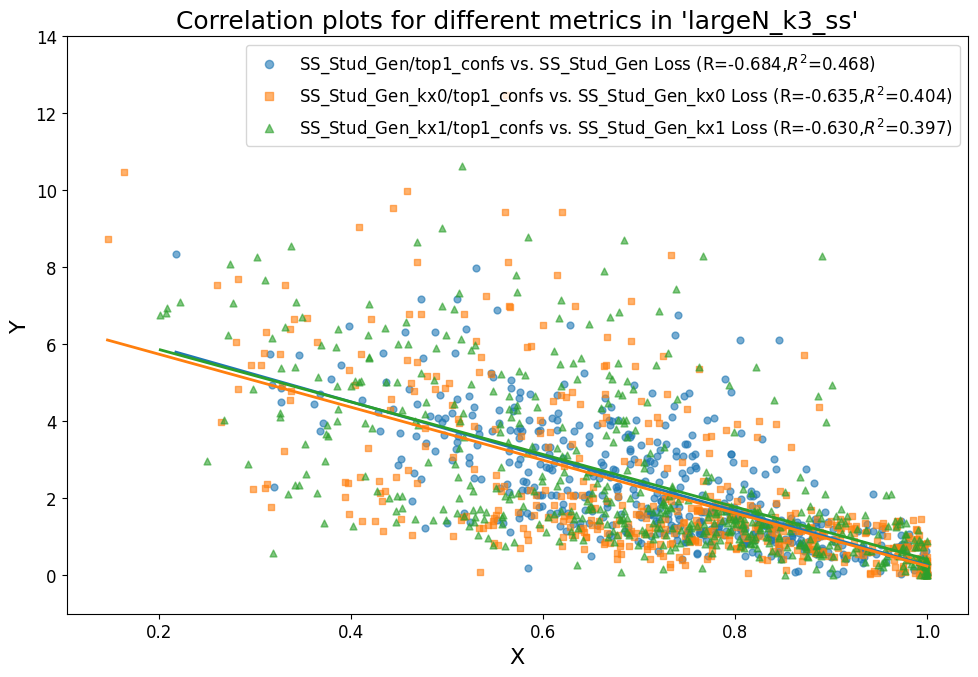

In [ ]:
# SAVE_FIGS = True
SAVE_FIGS = False

# same plot but this time plot on the same plot as legend entries for differen col pairs
# assume that it is fair to show them on same axes

# subsample = None
subsample = 500

all_col_pairs = [
    ["SS_Stud_Gen/top1_confs", "SS_Stud_Gen Loss"],
    ["SS_Stud_Gen_kx0/top1_confs", "SS_Stud_Gen_kx0 Loss"],
    ["SS_Stud_Gen_kx1/top1_confs", "SS_Stud_Gen_kx1 Loss"],
    ["SS_Stud_Gen_kx2/top1_confs", "SS_Stud_Gen_kx2 Loss"],
    # ["SS_Stud_Gen/ents", "SS_Stud_Gen Loss"],
    # ["SS_Stud_Gen/repetition_1", "SS_Stud_Gen Loss"],
    # ["SS_Stud_Gen_kx0/repetition_1", "SS_Stud_Gen_kx0 Loss"],
    # ["AR_Stud_Gen/repetition_1", "AR_Stud_Gen Loss"],
    # # ["AR_Stud_Gen/top1_confs", "AR_Stud_Gen Loss"],
]

markers = ['o', 's', '^', 'D', 'v', 'P', '*', 'X']

plt.figure(figsize=fig_size)

for i,cols in enumerate(all_col_pairs):
    if all(c in filtered_df.columns for c in cols):
        plot_df = filtered_df[cols].dropna()
        if subsample is not None and len(plot_df) > subsample:
            plot_df = plot_df.sample(n=subsample, random_state=42)
        if not plot_df.empty:
            if log_x:
                plot_df[cols[0]] = np.log(plot_df[cols[0]])
            if log_y:
                plot_df[cols[1]] = np.log(plot_df[cols[1]])
            r = plot_df.corr().iloc[0, 1]
            m, b = np.polyfit(plot_df[cols[0]], plot_df[cols[1]], 1)
            x = np.linspace(plot_df[cols[0]].min(), plot_df[cols[0]].max(), 100)

            plt.scatter(plot_df[cols[0]], plot_df[cols[1]], s=marker_size, marker=markers[i], alpha=0.6, label=f"{cols[0]} vs. {cols[1]} (R={r:.3f},$R^2$={r**2:.3f})")
            plt.plot(x, m * x + b)
        else:
            print(f"No data after dropping NA for columns: {cols}")
    else:
        missing = [c for c in cols if c not in filtered_df.columns]
        print(f"Missing columns: {missing}")

if y_axis_limits is not None:
    plt.ylim(y_axis_limits)

if log_x:
    plt.xlabel(f"log(X)")
else:
    plt.xlabel("X")
if log_y:
    plt.ylabel(f"log(Y)")
else:
    plt.ylabel("Y")
if reverse_x_axis:
    plt.gca().invert_xaxis()

if log_scale_x:
    plt.xscale("log")
if log_scale_y:
    plt.yscale("log")
plt.title(f"Correlation plots for different metrics in '{keystr}'")
plt.legend()
plt.tight_layout()

# save figure
fig_filename = f"corr_multiple_plots_{keystr}_steps_{int(step_min)}-{int(step_max)}.png"
print(f"Fig name: {fig_filename}")
if SAVE_FIGS:
    if not os.path.exists(FIGURES_OUT_DIR):
        os.makedirs(FIGURES_OUT_DIR)
    fig_path = os.path.join(FIGURES_OUT_DIR, fig_filename)
    plt.savefig(fig_path, bbox_inches='tight')

plt.show()